# 02 – Traditional ML Baselines for Automatic Modulation Classification

This notebook evaluates three classical machine-learning methods
(kNN, SVM, Random Forest) on the RadioML 2016.10A dataset using
precomputed feature vectors derived from the raw I/Q sequences.

The goals are to:

- Establish **traditional baselines** (kNN, SVM, Random Forest) on the same data used by the CNN/RNN models.
- Compare **accuracy, confusion patterns, and SNR-dependent performance**.
- Provide a reference point for how much the deep models gain over “standard” ML pipelines.

Reusing the same dataset, label mapping, and SNR metadata as in the CNN and RNN notebooks so results are directly comparable.

---


## 0 Setup & Required Files





### 0.1 Dataset on Google Drive

- **Dataset**  
  - `RadioML2016_10A_dataset.pkl`  
  - Expected path in this notebook:  
    `/content/drive/MyDrive/AMC_datasets/RadioML2016_10A_dataset.pkl`

> If you store this file in a different place, update `data_path` in the first
> code cell accordingly.


In [1]:
# Mount Google Drive (or configure to where dataset is located)
from google.colab import drive
drive.mount('/content/drive')

# Path to dataset (adjust this path to where the data file is located)
data_path = '/content/drive/MyDrive/AMC_datasets/RadioML2016_10A_dataset.pkl'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



### 0.2 GitHub Repository and Model Artifacts

GitHub repo: `Tutorial-Automatic-Modulation-Classification`

Cloned into:  `/content/Tutorial-Automatic-Modulation-Classification`



In [2]:
import os, sys
from pathlib import Path
REPO_URL = "https://github.com/Koosmaster/Tutorial-Automatic-Modulation-Classification.git"
REPO_DIR = Path("/content/Tutorial-Automatic-Modulation-Classification")
TRADITIONAL_DIR = REPO_DIR / "data" / "traditional_models"
SRC_DIR  = f"{REPO_DIR}/src"

if not os.path.isdir(REPO_DIR):
    !git clone --depth 1 "$REPO_URL" "$REPO_DIR"

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)


In [3]:
from data import load_radioml_pkl_dataset, radioml_splits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
import importlib, data_utils
importlib.reload(data_utils)
from data_utils import dict_to_iq_arrays, load_model_metrics, show_confusion


### 0.3 Load precomputed traditional-model results

The traditional ML baselines (kNN, SVM, RF) were already trained in a
separate script. That script saved:

- A global summary file (`summary.json`) with accuracy and timing for all
  three models.
- Three global plots:
  - `summary_accuracy.png` – overall accuracy comparison.
  - `summary_snr_accuracy.png` – accuracy vs SNR.
  - `summary_time.png` – training and evaluation time.
- Per-model folders:
  - `knn/metrics.json`, `knn/confusion.png`
  - `svm/metrics.json`, `svm/confusion.png`
  - `rf/metrics.json`, `rf/confusion.png`

In this notebook we *do not retrain* the models. Instead, we:

1. Load the JSON summaries into pandas DataFrames for the results tables.
2. Display the precomputed PNG figures (accuracy, SNR curves, confusion
   matrices).
3. Use these artifacts in Sections 5 and 6 to compare kNN, SVM, and RF and
   relate them to the CNN/RNN/Hybrid models.


In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Root directory where the traditional models saved their results
TRADITIONAL_DIR = REPO_DIR / "data" / "traditional_models"

print("Traditional-model results directory:", TRADITIONAL_DIR)
print("Exists:", TRADITIONAL_DIR.exists())

# ---- Overall summary table for Section 5.1 ----
summary_path = TRADITIONAL_DIR / "summary.json"
with open(summary_path, "r") as f:
    summary = json.load(f)

# Expect a dict like {"knn": {...}, "svm": {...}, "rf": {...}}
summary_df = pd.DataFrame(summary).T  # models as rows






Traditional-model results directory: /content/Tutorial-Automatic-Modulation-Classification/data/traditional_models
Exists: True


## 1 Experiment Overview



### 1.1 Notebook scope & goal

This notebook focuses only on **classical ML models** applied to AMC:

- **k-Nearest Neighbors (kNN)**
- **Support Vector Machines (SVM)**
- **Random Forests (RF)**

The **deep-learning models** are covered in separate notebooks:

- **03 – 1D CNN Ablation Study** – convolutional baselines  
- **04 – RNN Ablation Study** – recurrent baselines  
- **05 – Hybrid CNN–RNN** – ensembles of the best CNN and best RNN  

The main questions addressed:


- How strong are traditional ML baselines on this task?
- How do their confusion patterns and SNR behavior compare to the deep models?
- Where do they break down (e.g., low SNR, closely related modulations)?



### 1.2 Summary of main results

| Model | CV accuracy (%) | Test accuracy (%) | Train time (s) | Eval time (s) |
|:------|----------------:|------------------:|---------------:|--------------:|
| kNN   | 30.6            | 30.4              | 39.4           | 0.81          |
| SVM   | 45.6            | 45.7              | 2385.3         | 4.97          |
| RF    | 44.4            | 44.9              | 3364.6         | 1.18          |

*Note:* “CV accuracy” refers to the best mean cross-validated accuracy from `RandomizedSearchCV`.



## 2 Dataset & Features



### 2.1 Dataset summary

The **RadioML 2016.10A** dataset in the same form as the CNN/RNN experiments, but here we work with **feature vectors**:

- In this notebook, we specifically use **flattened I/Q vectors** as features:
each example is reshaped from `(2, 128)` complex baseband samples into a
256-dimensional real-valued feature vector `(256,)`.

The features may be:

- **Flattened I/Q samples** (used in this notebook), or  
- Handcrafted statistics derived from the I/Q sequences, or  
- Any other fixed-dimensional representation exported to `.npz`.


The data is teated as a **standard multiclass classification problem** over `num_classes` modulation labels.



### 2.2 Train / validation / test splits

We first create a 70/15/15 train/validation/test split, then merge
train+validation for cross-validated hyperparameter search, leaving the
15% test split for final evaluation.


This is the same train/validation/test split strategy as in the deep-learning experiments:

- **Training set:** used for hyperparameter search and model fitting.
- **Validation set:** used for cross-validation or for selecting final hyperparameters.
- **Test set:** held out for the final evaluation and all plots and tables in this notebook.

Each split includes an **SNR value per example**, which we use in
**Section 5.2** to build accuracy-vs-SNR curves.


In [5]:
radioml_data, mod_classes, snr_values = load_radioml_pkl_dataset(data_path)
X, y, snr_list = dict_to_iq_arrays(radioml_data)

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_temp, y_train, y_temp, snr_train, snr_temp = train_test_split(
    X, y_enc, snr_list, test_size=0.3, stratify=y_enc, random_state=42
)

X_val, X_test, y_val, y_test, snr_val, snr_test = train_test_split(
    X_temp, y_temp, snr_temp, test_size=0.5, stratify=y_temp, random_state=42
)


Loading RadioML 2016.10A dataset from: /content/drive/MyDrive/AMC_datasets/RadioML2016_10A_dataset.pkl
Found 11 raw modulation types.
Loaded dataset contains 11 modulation classes and 20 SNR values.
Dataset summary: 11 mods, 20 SNRs, 220,000 total samples.




---

## 3 Models & Hyperparameters
Tables 1–4 summarize the model families and hyperparameter search spaces used.


### 3.1 k-Nearest Neighbors (kNN)

**Table 1 – kNN configuration.**

| Aspect           | Choices / Description                                      |
|------------------|-----------------------------------------------------------|
| Number of neighbors `k` | Discrete values such as `[3, 5, 7, 9]` (tuned by CV). |
| Distance metric  | Euclidean distance (standard L2) in the feature space.   |
| Weighting scheme | Either **uniform** weights or **distance-based** weights (closer neighbors contribute more). |

**High-level notes**

- kNN is **non-parametric and simple**, but evaluation cost grows with **dataset size** because each query compares against many training points.  
- Performance depends heavily on the feature representation being **well-scaled and well-separated**; poor scaling or noisy features can hurt kNN more than other models.


### 3.2 Support Vector Machines (SVM)

**Table 2 – SVM configuration.**

| Aspect                    | Choices / Description                                                |
|---------------------------|----------------------------------------------------------------------|
| Kernel type               | RBF                                                                  |
| Regularization parameter  | `C` (tuned over a discrete set of values)                           |
| Kernel width              | `gamma` for the RBF kernel (tuned jointly with `C`)                 |
| Output type | Hard class labels via `predict` (probability estimates are disabled to reduce compute) |


**High-level notes**

- SVMs with RBF kernels can form **very flexible decision boundaries**.  
- Training can be **computationally expensive** on large datasets, but SVMs often provide **strong baseline performance** for fixed feature vectors.


### 3.3 Random Forest (RF)

**Table 3 – Random Forest configuration.**

| Aspect                        | Choices / Description                                                    |
|-------------------------------|--------------------------------------------------------------------------|
| Number of trees               | `n_estimators` (e.g., up to 800 trees in the best model)                |
| Maximum tree depth            | `max_depth` (controls model capacity)                                   |
| Minimum samples per split     | `min_samples_split`                                                     |
| Minimum samples per leaf      | `min_samples_leaf`                                                      |
| Feature subsampling strategy  | `max_features` per split (controls randomness and decorrelation)        |

**High-level notes**

- RFs are **ensemble methods** that average many decision trees.  
- They handle **non-linear structure** and heterogeneous features well.  
- Careful tuning of depth and leaf size is needed to balance **overfitting vs underfitting**.


### 3.4 Hyperparameter search (CPU + GPU variants)

**Table 4 – Hyperparameter search strategy.**

| Component        | CPU path                                      | GPU path (optional)                          | Notes                                                   |
|------------------|-----------------------------------------------|----------------------------------------------|---------------------------------------------------------|
| Search algorithm | `RandomizedSearchCV`                          | Manual random search loop                    | Same hyperparameter ranges used for both when possible. |
| CV scheme        | `StratifiedKFold` (e.g., 3–5 folds)          | Stratified splits implemented manually       | Preserves class balance across folds.                   |
| Models covered   | kNN, SVM, RF                                  | cuML versions of kNN / SVM / RF              | GPU path used only when available.                      |
| Budget knobs     | Number of random samples, number of CV folds, time budget | Same knobs, adjusted for GPU speed | Goal is **comparable effort**, not perfect global opt.  
|Budget parameters  | 5 CV folds, 20 random samples per model (same for CPU and GPU) |



The goal of this search is **not** to perfectly optimize each model, but
to give kNN, SVM, and RF a **reasonable and comparable hyperparameter
tuning budget**.
Additionally, use 5-fold StratifiedKFold and 20 random hyperparameter samples per model.



## 4 Training & Evaluation Procedure

In this section, we:

1. Load the `.npz` file into memory and construct numpy arrays for  
   `X_train, y_train, X_val, y_val, X_test, y_test` and (optionally) `SNR`.
2. Standardize features (e.g., `StandardScaler` on the training data) and apply the same transform to val/test.
   -  For kNN and SVM we apply StandardScaler inside a sklearn Pipeline; RF is trained on the raw (unscaled) features.

3. For each model type (kNN / SVM / RF):
   - Run hyperparameter search using stratified cross-validation on the training set.
   - Select the best hyperparameters based on validation performance.
   - Refit the model on the **combined train+validation data** (optional).
   - Evaluate on the held-out **test set**.
4. Compute metrics:
   - Overall test accuracy
   - Per-class precision/recall/F1 or a classification report
   - Confusion matrix
   - Accuracy vs SNR (if SNR metadata is available)
5. Save all intermediate results (best hyperparameters, scores, confusion matrices, SNR curves) to `OUT_DIR` for reuse by other notebooks or the final report.



---

## 5 Results

Using the configurations in Tables 1–4, we obtain the following performance results



### 5.1 Quantitative summary

**Table 5 – Traditional ML baselines on RadioML 2016.10A (feature-based).**

| Model | CV accuracy (%) | Test accuracy (%) | Train time (s) | Eval time (s) |
|-------|-----------------|-------------------|----------------|---------------|
| kNN   | 30.6            | 30.4              | 39.4           | 0.81          |
| SVM   | 45.6            | 45.7              | 2385.3         | 4.97          |
| RF    | 44.4            | 44.9              | 3364.6         | 1.18          |

“CV accuracy” refers to the best mean cross-validated accuracy from RandomizedSearchCV.
- **Best accuracy:** SVM, with RF close behind.  
- **Cheapest compute:** kNN (fastest train + eval, but much lower accuracy).


In [6]:
# Load overall summary (kNN / SVM / RF)
summary_path = TRADITIONAL_DIR / "summary.json"
with open(summary_path, "r") as f:
    summary = json.load(f)

summary_df = pd.DataFrame(summary).T  # models as rows

display(summary_df)
cols_for_table = [
    c for c in summary_df.columns
    if any(k in c.lower() for k in ["cv", "val", "test", "time"])
]



,cv_accuracy,test_accuracy,best_params,train_time_sec,test_time_sec,snr_curve
knn,0.305513,0.304061,{'n_neighbors': 5},39.398135,0.809919,"{'snr': [-20, -18, -16, -14, -12, -10, -8, -6,..."
svm,0.456428,0.457485,"{'C': 8, 'gamma': 0.01}",2385.259744,4.970247,"{'snr': [-20, -18, -16, -14, -12, -10, -8, -6,..."
rf,0.444449,0.449394,"{'n_estimators': 800, 'max_depth': 24, 'max_fe...",3364.643702,1.179569,"{'snr': [-20, -18, -16, -14, -12, -10, -8, -6,..."



### 5.2 Accuracy vs SNR

Compute accuracy as a function of SNR for each model:

1. Group test examples by SNR value.  
2. For each SNR, compute the fraction of correctly classified samples.  
3. Plot one curve per model.

This reveals:

- How quickly each model **degrades as SNR decreases**.
- Whether some models are **more stable at low SNR**, even if their overall accuracy is similar.

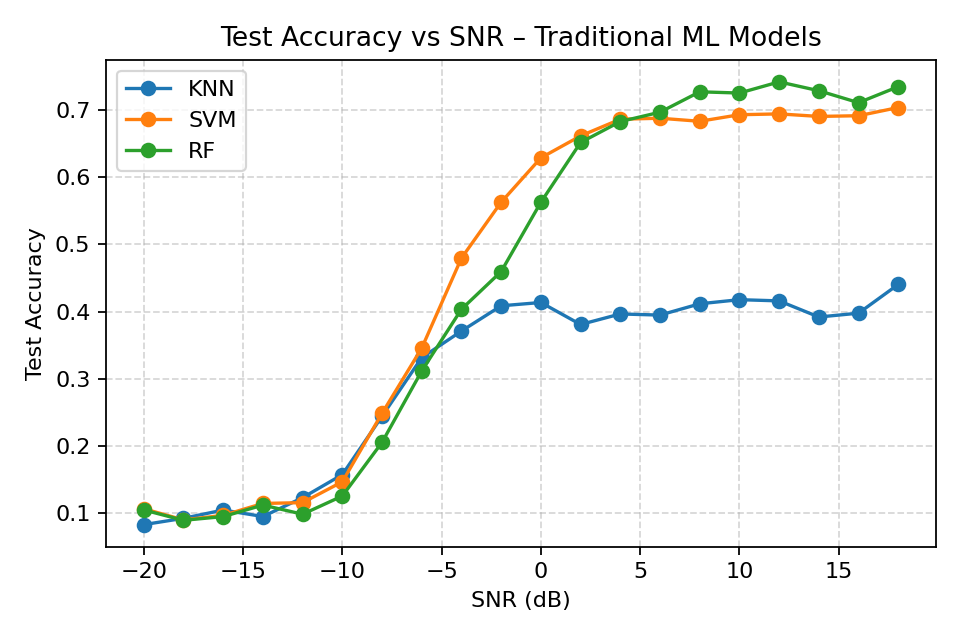

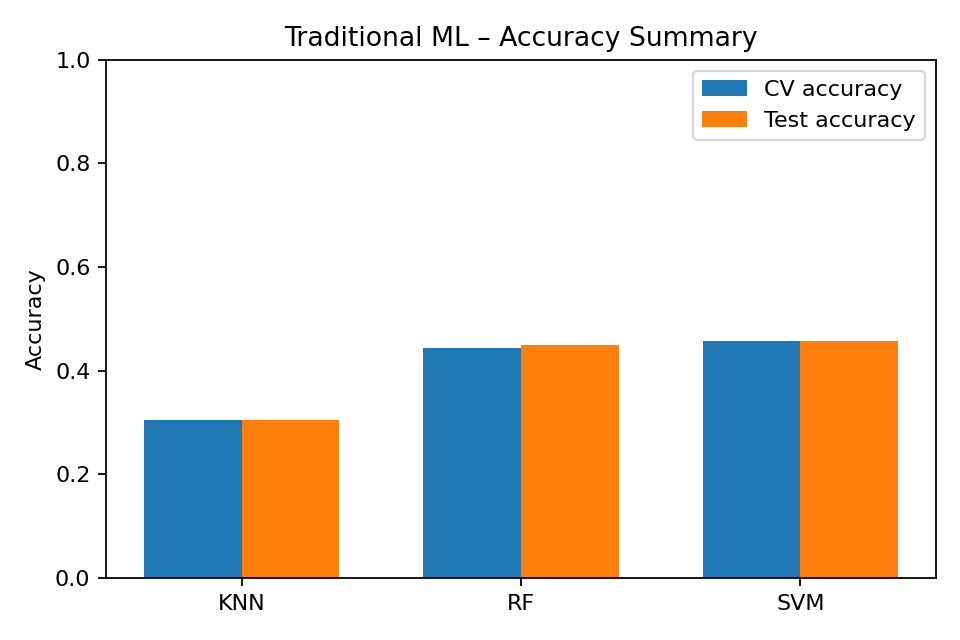

In [13]:
# Accuracy vs SNR
display(Image(filename=str(TRADITIONAL_DIR / "summary_snr_accuracy.png")))
# Overall accuracy comparison (can be referenced in 5.1/5.2)
display(Image(filename=str(TRADITIONAL_DIR / "summary_accuracy.png")))




In [8]:
knn_metrics = load_model_metrics("knn")
svm_metrics = load_model_metrics("svm")
rf_metrics  = load_model_metrics("rf")


### 5.3 Confusion matrices

For each model, compute and visualize a confusion matrix on the test set:

- **Rows:** true modulation labels  
- **Columns:** predicted modulation labels  
- Each cell shows either **counts** or **normalized frequencies**.

Comparing confusion matrices reveals:

- Which modulations are consistently confused (e.g., adjacent PSK/QAM classes).
- Whether certain models tend to **“collapse” similar modulations into a single class** at low SNR.


---

**KNN**

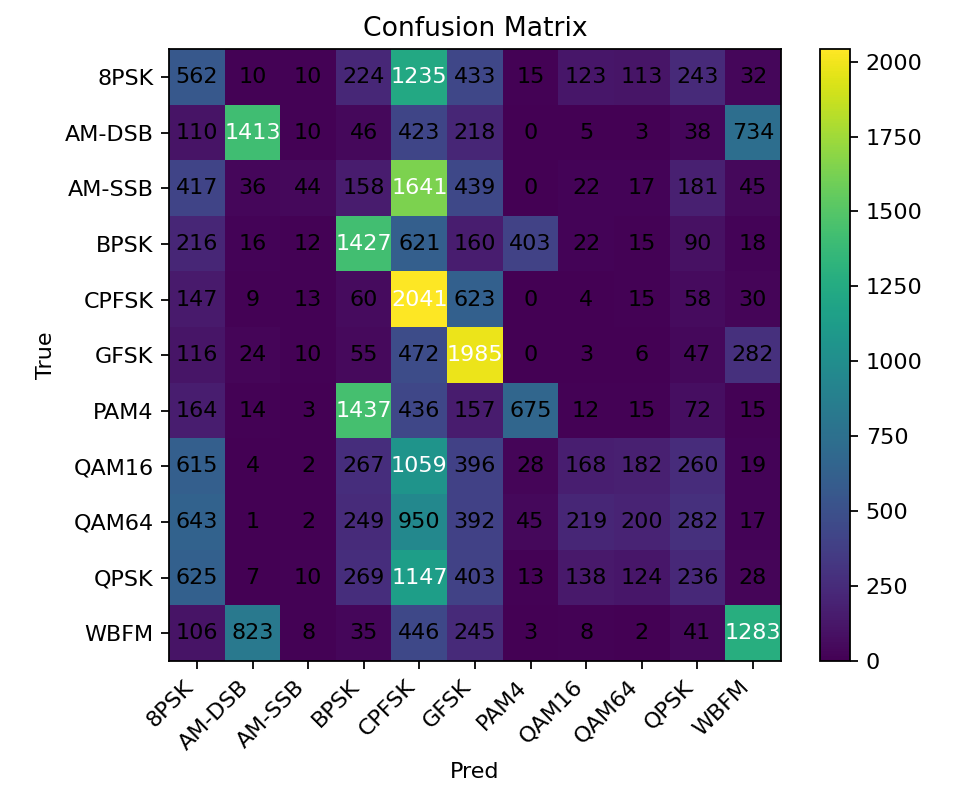

In [9]:
show_confusion("knn")



**SVM**

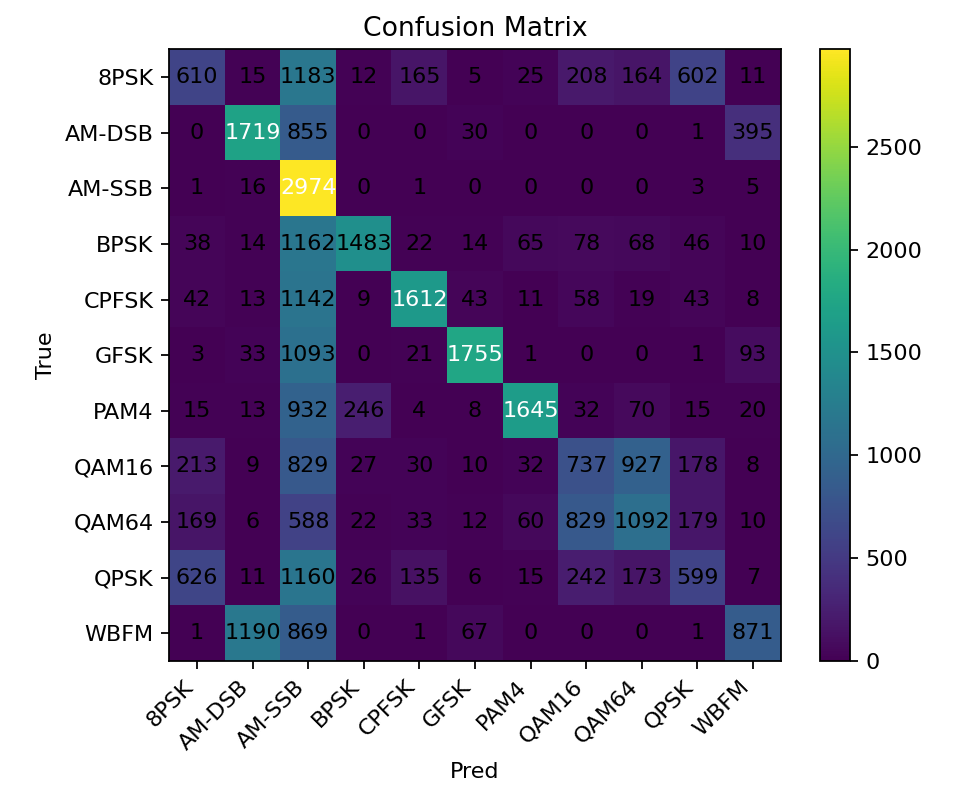

In [10]:
show_confusion("svm")


**RF**

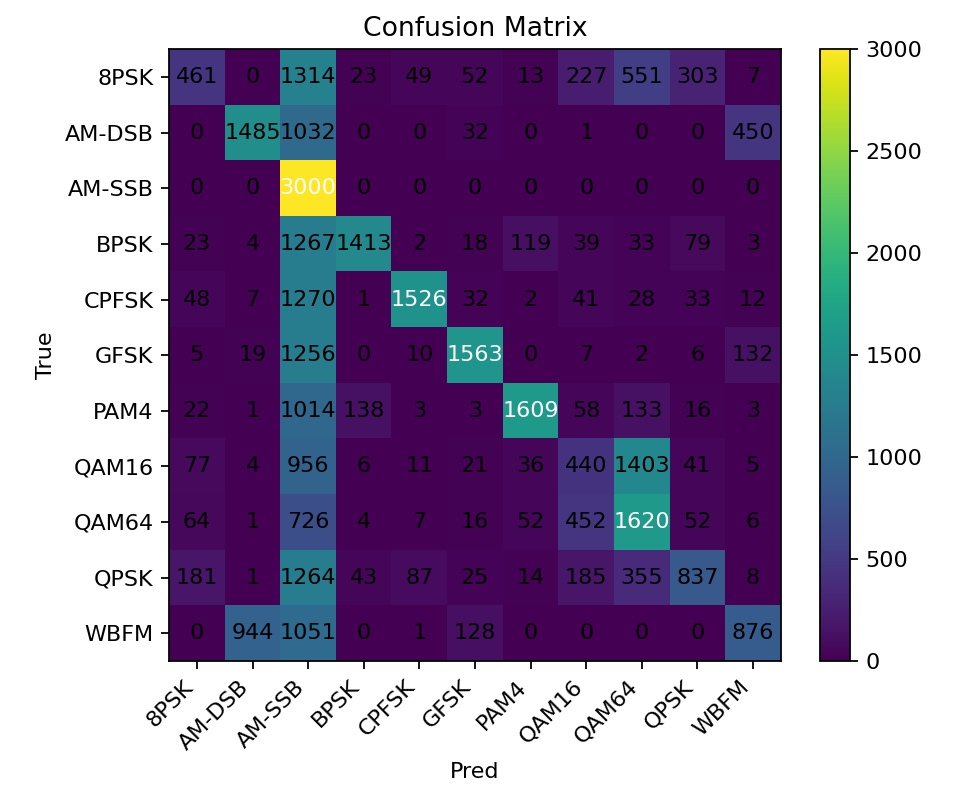

In [11]:
show_confusion("rf")



---


## 6 Discussion & Takeaways

This section interprets the traditional ML baselines and sets them up
for comparison with the CNN, RNN, and hybrid models.


### 6.1 Relative performance (at a glance)

**Table 6 – High-level comparison of traditional models.**

| Model | Accuracy level | Gap to best traditional | Qualitative verdict |
|-------|----------------|-------------------------|---------------------|
| kNN   | Low (~30% test) | −15–16 percentage points vs SVM | Clearly weaker baseline; mainly useful as a very simple reference. |
| SVM   | Highest (~46% test) | – | Strongest traditional baseline on these features. |
| RF    | High (~45% test) | ≈ 1 point below SVM | Competitive with SVM; slightly lower accuracy but similar behavior. |


### 6.2 SNR behavior

**Table 7 – Qualitative SNR behavior by model.**

| SNR regime          | kNN                                   | SVM / RF                                           | Deep models (CNN/RNN, from other notebooks)        |
|---------------------|---------------------------------------|----------------------------------------------------|----------------------------------------------------|
| Very low SNR        | Near random; no clear structure.      | Also near random; only slight improvements.       | Still low, but noticeably better than traditional. |
| Mid SNR             | Improves, but remains far behind best.| SVM/RF clearly outperform kNN and diverge from it. | Strong advantage; curves are consistently higher.  |
| High SNR            | Saturates at ~30% overall accuracy.   | Saturate near their max (~45% test).              | Highest plateau; best separation of modulations.   |




### 6.3 Confusion patterns

**Table 8 – Confusion patterns across traditional models.**

| Aspect                         | kNN                                           | SVM                                           | RF                                            |
|--------------------------------|-----------------------------------------------|-----------------------------------------------|-----------------------------------------------|
| Diagonal sharpness             | Weakest; many off-diagonal entries.          | Sharper diagonal than kNN.                    | Similar to SVM; sharp diagonal.               |
| Hard modulation pairs          | Struggles with closely related PSK/QAM, AM variants (same as others). | Same difficult pairs as kNN.                  | Same difficult pairs as kNN/SVM.              |
| Behavior at low SNR            | Confusions spread widely across many classes.| Confusions still structured but more diffuse. | Similar to SVM; some collapse of similar mods.|
| Overall impression             | Noisy, “blurry” confusion matrix.            | Reasonable structure with clear error modes.  | Very similar structure to SVM.                |




### 6.4 Compute tradeoffs

**Table 9 – Accuracy vs compute tradeoffs.**

| Model | Accuracy | Train cost | Inference cost | When it makes sense to use |
|-------|----------|------------|----------------|----------------------------|
| kNN   | ★☆☆ – low (~30%) | ★★☆ – very cheap (tens of seconds) | ★★★ – fastest (≈ 0.8 s) | Quick sanity check / toy baseline when compute is extremely limited. |
| SVM   | ★★★ – best (~46%) | ★☆☆ – expensive (≈ 40 min) | ★☆ – slowest (≈ 5 s) | Highest traditional accuracy when training time is acceptable. |
| RF    | ★★☆ – high (~45%) | ★☆☆ – most expensive (≈ 56 min) | ★★☆ – moderate (≈ 1.2 s) | Good compromise: near-SVM accuracy with cheaper inference. |

(“Stars” are qualitative; the numbers come from Table 5.)


RF is a reasonable compromise: accuracy close to SVM, faster inference, and a
well-understood implementation. For this project, however, these
results mainly serve as a **baseline benchmark** for the deep-learning
architectures studied in the other notebooks.

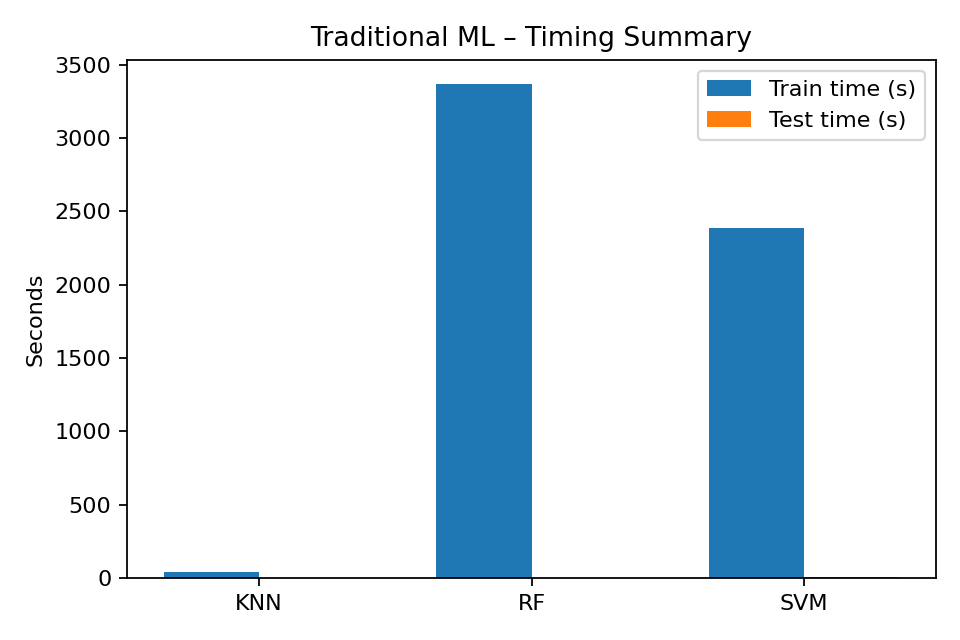

In [12]:
display(Image(filename=str(TRADITIONAL_DIR / "summary_time.png")))
